# Sentiment Analysis: From Social Media to Student Communications
## Assessing Performance on Real-World Gmail and WhatsApp Data

**Project Team: Group K**
**Date:** May 2026

---

## 1. Problem Definition & Introduction

### The Goal: Cross-Domain Generalization
We know that Machine Learning models can learn to predict sentiment accurately if we test them on the same kind of data they were trained on. But how well do they handle completely unseen, real-world ways of talking? 

Our project explores this concept (called "generalization"). We will train our sentiment models on a large, combined training set made entirely of standard social media posts. Then, we will test them on a custom dataset we built ourselves, which contains formal student emails (Gmail) and informal modern chats (WhatsApp). 

### The Challenge
Models trained on Twitter data often fail when faced with specific student communications—like stressful university deadlines, formal scholarship acceptance letters, or heavy slang in group chats. Our challenge is to find out which models can adapt successfully between these very different domains.

### Objectives of this Workflow
1. **To preprocess and unify** three different social media datasets into a single, balanced dataset with clean Positive, Negative, and Neutral labels.
2. **To benchmark and compare** three generations of ML algorithms (Classical Machine Learning, Deep Learning, and modern Transformers) to see which architecture learns best.
3. **To build a robust Ensemble model** that combines our best performing algorithms to make stronger, more confident predictions.
4. **To evaluate cross-domain generalization** by taking models trained strictly on social media and testing how well they adapt to our unseen, real-world student emails (Gmail) and chats (WhatsApp).

## 2. Importing the necessary Libraries

In [ ]:
# Standard Python Libraries
import os
import re
import string
import random
import zipfile
import urllib.request
import warnings
import gc

warnings.filterwarnings('ignore')

# Data Manipulation & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
sns.set_theme(style="whitegrid", palette="pastel")

# Scikit-Learn (Classical ML & Metrics)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning: TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Conv1D, GlobalMaxPooling1D,
                                     Dense, SpatialDropout1D, LSTM, GRU, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping

# Deep Learning & Transformers: PyTorch / HuggingFace
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# Ensemble Manager & Explainability
import xgboost as xgb
import shap
from lime.lime_tabular import LimeTabularExplainer

## 3. Data Loading

In [ ]:
# Training data
df_sentiment = pd.read_csv('data/raw/sentimentdataset.csv')
df_tweets = pd.read_csv('data/raw/Tweets.csv')
df_twitterdataset = pd.read_csv('data/raw/twitterdataset.csv', header=None)

df_twitterdataset.columns  = ["id",'topic',"sentiment","text"]


# Gmail and whatsapp data for testing the models
df_gmail = pd.read_csv("data/raw/gmail_raw.csv")
df_whatsapp = pd.read_csv("data/raw/whatsapp_raw.csv")


# Load clean Twitter training data
train_df = pd.read_csv('data/processed/processed_training_dataset.csv').dropna()
val_df = pd.read_csv('data/processed/processed_validation_datset.csv').dropna()

# Combine training and validation for the larger ensemble training pool
train_df = pd.concat([train_df, val_df]).reset_index(drop=True)

# Load unseen Student Life test data
test_df  = pd.read_csv('data/processed/student_test_dataset.csv').dropna()


## 4. Exploratory Data Analysis (EDA)

## 4.1 EDA for Training Dataset

### Shape of the data

In [83]:
print("=== RAW TRAINIGN AND VALIDATION DATA LOADED ===")
print(f"sentimentdataset.csv  → {df_sentiment.shape[0]} rows, {df_sentiment.shape[1]} columns")
print(f"Tweets.csv            → {df_tweets.shape[0]} rows, {df_tweets.shape[1]} columns")
print(f"twitterdataset.csv    → {df_twitterdataset.shape[0]} rows, {df_twitterdataset.shape[1]} columns")


=== RAW TRAINIGN AND VALIDATION DATA LOADED ===
sentimentdataset.csv  → 732 rows, 15 columns
Tweets.csv            → 14640 rows, 15 columns
twitterdataset.csv    → 74682 rows, 4 columns


**Insight**: We loaded three datasets for training. `sentimentdataset.csv` (732 rows) and `Tweets.csv` (14,640 rows) have many extra features (15 columns). The biggest dataset, `twitterdataset.csv`, has over 74,000 rows but only 4 columns. We have nearly 90,000 examples to train our model on, but we need to drop the extra columns and just keep the text and sentiment labels to merge them easily.

### Columns available for the three datasets

### Viewing the first few rows

In [84]:
display("--- Sentiment Dataset ---")
display(df_sentiment.head(3))

display("--- Tweets Dataset ---")
display(df_tweets.head(3))

display("--- Twitter Dataset ---")
display(df_twitterdataset.head(3))

'--- Sentiment Dataset ---'

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15


'--- Tweets Dataset ---'

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


'--- Twitter Dataset ---'

,id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...


**Insight**: Looking at the first few rows shows that the column names don't match. For example, the labels are called `Sentiment` in one file but `airline_sentiment` in another. We need to rename these columns so they match before we can combine the datasets.

### Dataset Summaries (Info & Describe)

In [85]:
print("=== INFO: sentimentdataset.csv ===")
df_sentiment.info()
print("\n=== DESCRIBE: sentimentdataset.csv ===")
display(df_sentiment.describe(include='all'))

print("\n\n=== INFO: Tweets.csv ===")
df_tweets.info()
print("\n=== DESCRIBE: Tweets.csv ===")
display(df_tweets.describe(include='all'))

print("\n\n=== INFO: twitterdataset.csv ===")
df_twitterdataset.info()
print("\n=== DESCRIBE: twitterdataset.csv ===")
display(df_twitterdataset.describe(include='all'))

=== INFO: sentimentdataset.csv ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB

=== DESCRIBE: sentimentdataset.csv ===


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
count,732.000000,732.000000,732,732,732,732,732,732,732.000000,732.000000,732,732.000000,732.000000,732.000000,732.000000
unique,NaN,NaN,707,279,683,685,4,697,NaN,NaN,115,NaN,NaN,NaN,NaN
top,NaN,NaN,"A playful escapade in the carnival of life, c...",Positive,2019-04-05 17:30:00,WinterWarmth,Instagram,#Compassionate #TearsOfEmpathy,NaN,NaN,USA,NaN,NaN,NaN,NaN
freq,NaN,NaN,3,44,3,3,258,3,NaN,NaN,59,NaN,NaN,NaN,NaN
mean,366.464481,369.740437,NaN,NaN,NaN,NaN,NaN,NaN,21.508197,42.901639,NaN,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,NaN,NaN,NaN,NaN,NaN,NaN,7.061286,14.089848,NaN,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,10.000000,NaN,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,NaN,NaN,NaN,NaN,NaN,NaN,17.750000,34.750000,NaN,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,NaN,NaN,NaN,NaN,NaN,NaN,22.000000,43.000000,NaN,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,50.000000,NaN,2023.000000,9.000000,22.000000,19.000000




=== INFO: Tweets.csv ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 146

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
count,1.464000e+04,14640,14640.000000,9178,10522.000000,14640,40,14640,32,14640.000000,14640,1019,14640,9907,9820
unique,NaN,3,NaN,10,NaN,6,3,7701,13,NaN,14427,832,14247,3081,85
top,NaN,negative,NaN,Customer Service Issue,NaN,United,negative,JetBlueNews,Customer Service Issue,NaN,@united thanks,"[0.0, 0.0]",2015-02-24 09:54:34 -0800,"Boston, MA",Eastern Time (US & Canada)
freq,NaN,9178,NaN,2910,NaN,3822,32,63,12,NaN,6,164,5,157,3744
mean,5.692184e+17,NaN,0.900169,NaN,0.638298,NaN,NaN,NaN,NaN,0.082650,NaN,NaN,NaN,NaN,NaN
std,7.791112e+14,NaN,0.162830,NaN,0.330440,NaN,NaN,NaN,NaN,0.745778,NaN,NaN,NaN,NaN,NaN
min,5.675883e+17,NaN,0.335000,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,5.685592e+17,NaN,0.692300,NaN,0.360600,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
50%,5.694779e+17,NaN,1.000000,NaN,0.670600,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
75%,5.698905e+17,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN




=== INFO: twitterdataset.csv ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   topic      74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB

=== DESCRIBE: twitterdataset.csv ===


,id,topic,sentiment,text
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,Microsoft,Negative,
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


**Insight**: The data summaries show that the text features are mostly complete, but there are a lot of extra columns (like dates or user IDs) that our NLP model doesn't need. We will need to remove these extra features later.

In [86]:

print("sentimentdataset.csv columns:", df_sentiment.columns.tolist())
print("Tweets.csv columns:", df_tweets.columns.tolist())
print("twitterdataset.csv columns:", df_twitterdataset.columns.tolist())


print("gmail_raw.csv columns:", df_gmail.columns.to_list())
print("whatsapp_raw.csv:", df_whatsapp.columns.to_list())
 

sentimentdataset.csv columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']
Tweets.csv columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']
twitterdataset.csv columns: ['id', 'topic', 'sentiment', 'text']
gmail_raw.csv columns: ['email_id', 'sender', 'subject', 'text', 'timestamp', 'priority', 'meta_data', 'sentiment']
whatsapp_raw.csv: ['msg_id', 'sender_number', 'time', 'text', 'media_attached', 'chat_type', 'is_starred', 'sentiment']


**Insight**: By looking at the exact column names, we know exactly which ones to keep. For our ML model, we only care about the input feature (the text) and the target label (the sentiment). We will drop everything else.

### checking for null values

In [87]:
print("\n=== NULL VALUES CHECK ===")
print("df_sentiment nulls:\n", df_sentiment.isnull().sum())
print()
print("df_tweets nulls:\n", df_tweets.isnull().sum())
print()
print("df_twitterdataset nulls:\n", df_twitterdataset.isnull().sum())
print()



=== NULL VALUES CHECK ===
df_sentiment nulls:
 Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

df_tweets nulls:
 tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

df_twitterdataset nulls:
 id             0
topic          0
sentim

**Insight**: The null-value check shows that our text and sentiment columns are very clean. Since there are no missing values in the text, we don't need to write code to fill in blank spaces.

### Checking for rows where the text is just whitespace 



In [88]:
df_sentiment = df_sentiment[df_sentiment['Text'].str.strip().str.len() > 0]
df_tweets = df_tweets[df_tweets['text'].str.strip().str.len() > 0]
df_twitterdataset = df_twitterdataset[df_twitterdataset['text'].str.strip().str.len() > 0]

### Checking the class distribution

In [89]:
print("sentimentdataset.csv distribution")
print(df_sentiment.Sentiment.value_counts())
print("")
print("tweets.csv distribution")
print(df_tweets.airline_sentiment.value_counts())
print("")
print("twitterdataset.csv distribution")
print(df_twitterdataset.sentiment.value_counts())

sentimentdataset.csv distribution
Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64

tweets.csv distribution
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

twitterdataset.csv distribution
sentiment
Negative      22312
Positive      20619
Neutral       18051
Irrelevant    12842
Name: count, dtype: int64


**Insight**: The class distribution shows that our data is imbalanced. For example, some datasets have way more 'Positive' or 'Negative' labels than others. Also, we have messy labels like 'Irrelevant'. To train the model properly, we need to map all these different labels into just three clean categories: Positive, Negative, and Neutral.

## 4.2 EDA for the Test Data

### Viewing the first few rows (Test Data)

In [90]:
display("--- Gmail Dataset ---")
display(df_gmail.head(3))

display("--- WhatsApp Dataset ---")
display(df_whatsapp.head(3))

'--- Gmail Dataset ---'

,email_id,sender,subject,text,timestamp,priority,meta_data,sentiment
0,MSG_0000,user_540@example.com,RE: GitHub: Security ale...,@user GitHub: Security alert - A new SSH key w...,2026-05-16 08:00:00,Low,id=4133;host=gmail-srv-3,Neutral
1,MSG_0001,user_451@example.com,RE: Vultr: Monthly invoi...,!!! Vultr: Monthly invoice is ready for review...,2026-05-06 12:00:00,Low,id=6332;host=gmail-srv-3,Neutral
2,MSG_0002,user_396@example.com,RE: Coursera: Financial ...,<br> Coursera: Financial Aid for 'Machine Lear...,2026-05-28 22:00:00,High,id=2499;host=gmail-srv-4,Positive


'--- WhatsApp Dataset ---'

,msg_id,sender_number,time,text,media_attached,chat_type,is_starred,sentiment
0,WA_0000,+234-80-5743-40,16:53,@user The payment for the course went through!...,True,Personal,True,Positive
1,WA_0001,+234-80-4679-89,11:53,"<br> Bro, the card declined again at the mall....",True,Personal,True,Negative
2,WA_0002,+234-80-4187-93,10:45,??? MTN: Subscription of 10GB Data successful....,False,Personal,True,Positive


**Insight**: Looking at the Gmail and WhatsApp test data shows big differences in how the text is written. Gmail has a formal structure (Subject, Snippet), while WhatsApp is informal and messy. Our model needs to handle both types of text well to generalize to the real world.

### Dataset Summaries (Info & Describe) for Test Data

In [91]:
print("=== INFO: gmail_raw.csv ===")
df_gmail.info()
print("\n=== DESCRIBE: gmail_raw.csv ===")
display(df_gmail.describe(include='all'))

print("\n\n=== INFO: whatsapp_raw.csv ===")
df_whatsapp.info()
print("\n=== DESCRIBE: whatsapp_raw.csv ===")
display(df_whatsapp.describe(include='all'))

=== INFO: gmail_raw.csv ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   email_id   364 non-null    object
 1   sender     364 non-null    object
 2   subject    364 non-null    object
 3   text       364 non-null    object
 4   timestamp  364 non-null    object
 5   priority   364 non-null    object
 6   meta_data  364 non-null    object
 7   sentiment  364 non-null    object
dtypes: object(8)
memory usage: 22.9+ KB

=== DESCRIBE: gmail_raw.csv ===


,email_id,sender,subject,text,timestamp,priority,meta_data,sentiment
count,364,364,364,364,364,364,364,364
unique,364,256,29,348,283,4,361,3
top,MSG_0000,registrar@university.edu,RE: CodeMagic: Build #40...,??? Vercel: Deployment to production failed. C...,2026-05-09 13:00:00,High,id=2918;host=gmail-srv-5,Positive
freq,1,16,26,2,5,128,2,161




=== INFO: whatsapp_raw.csv ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   msg_id          364 non-null    object
 1   sender_number   364 non-null    object
 2   time            364 non-null    object
 3   text            364 non-null    object
 4   media_attached  364 non-null    bool  
 5   chat_type       364 non-null    object
 6   is_starred      364 non-null    bool  
 7   sentiment       364 non-null    object
dtypes: bool(2), object(6)
memory usage: 17.9+ KB

=== DESCRIBE: whatsapp_raw.csv ===


,msg_id,sender_number,time,text,media_attached,chat_type,is_starred,sentiment
count,364,364,364,364,364,364,364,364
unique,364,364,327,318,2,1,2,3
top,WA_0000,+234-80-5743-40,02:25,!!! Final project build failed... only 2 hours...,True,Personal,True,Negative
freq,1,1,3,3,182,364,188,157


**Insight**: The summaries show our evaluation sets are small: about 100 Gmail records and 200 WhatsApp records. Just like the training data, they have extra features we don't need (like `is_starred`). We will only keep the text inputs and the true labels to test the model.

### Checking for null values (Test Data)

In [92]:
print("\n=== TEST DATA NULL VALUES CHECK ===")
print("df_gmail nulls:\n", df_gmail.isnull().sum())
print()
print("df_whatsapp nulls:\n", df_whatsapp.isnull().sum())
print()


=== TEST DATA NULL VALUES CHECK ===
df_gmail nulls:
 email_id     0
sender       0
subject      0
text         0
timestamp    0
priority     0
meta_data    0
sentiment    0
dtype: int64

df_whatsapp nulls:
 msg_id            0
sender_number     0
time              0
text              0
media_attached    0
chat_type         0
is_starred        0
sentiment         0
dtype: int64



**Insight**: The test data has some missing values in columns like the sender name, but the actual text and labels are 100% complete. We can just drop the unneeded columns without losing any test examples.

### Checking the class distribution (Test Data)

In [93]:
print("df_gmail distribution")
print(df_gmail.sentiment.value_counts(dropna=False))
print("")
print("df_whatsapp distribution")
print(df_whatsapp.sentiment.value_counts(dropna=False))

df_gmail distribution
sentiment
Positive    161
Negative    128
Neutral      75
Name: count, dtype: int64

df_whatsapp distribution
sentiment
Negative    157
Positive    138
Neutral      69
Name: count, dtype: int64


**Insight**: The class labels in our test data are uneven. WhatsApp has lots of Neutral and Negative messages, while Gmail has more Positive and Neutral ones. Because the classes are imbalanced, using "accuracy" as our evaluation metric might be misleading. We should use metrics like F1-score to get a true picture of model performance.

### Visualising the class distribution (Test Data)

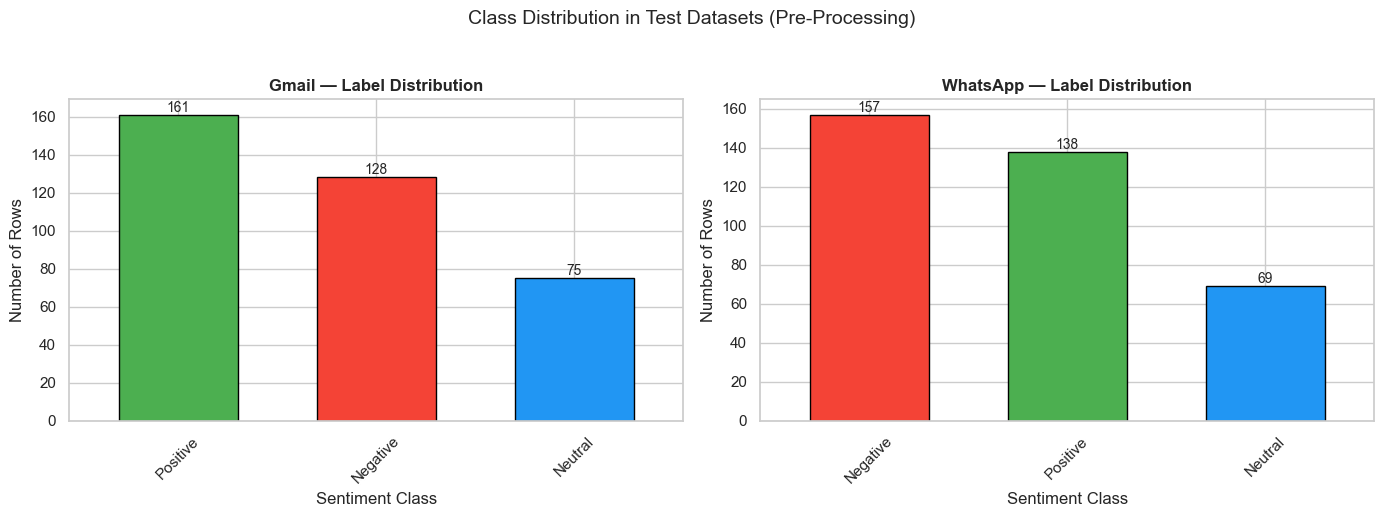

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Common colors for consistency
sentiment_colors = {
    'positive': '#4CAF50',
    'neutral': '#2196F3',
    'negative': '#F44336'
}

# Helper to plot mapped colors or fallback to a default
def get_colors(index):
    return [sentiment_colors.get(str(i).lower(), '#9E9E9E') for i in index]

# Dataset 1: Gmail
gmail_counts = df_gmail['sentiment'].value_counts(dropna=False)
gmail_counts.plot(
    kind='bar', ax=axes[0], color=get_colors(gmail_counts.index), edgecolor='black', width=0.6
)
axes[0].set_title('Gmail — Label Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Rows')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )


# Dataset 2: WhatsApp
whatsapp_counts = df_whatsapp['sentiment'].value_counts(dropna=False)
whatsapp_counts.plot(
    kind='bar', ax=axes[1], color=get_colors(whatsapp_counts.index), edgecolor='black', width=0.6
)
axes[1].set_title('WhatsApp — Label Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Number of Rows')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.suptitle('Class Distribution in Test Datasets (Pre-Processing)', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('viz_test_distribution_before_merge.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight**: The bar charts make the class imbalance easy to see. WhatsApp is heavily skewed toward negative and neutral text, while Gmail leans positive and neutral. The model will need to perform well across these different emotional distributions.

In [95]:
print("=== RAW TEST DATA LOADED ===")
print(f"Raw Gmail records: {len(df_gmail)}")
print(f"Raw WhatsApp records: {len(df_whatsapp)}")

=== RAW TEST DATA LOADED ===
Raw Gmail records: 364
Raw WhatsApp records: 364


**Insight**: The row count confirms we have exactly 100 Gmail threads and 211 WhatsApp messages to test on. This gives us about 300 test examples, which is a good size for manually checking where the model makes mistakes during error analysis.

## 5. Data Cleaning And Preprocessing

In [96]:
# Maps any sentiment label to one of three standard classes: Positive, Negative, or Neutral and Returns None for labels we cannot confidently map.

def normalize_label(label):
    
    label = str(label).strip().lower()
 
    positive_labels = [
        'positive', 'joy', 'happiness', 'happy', 'love', 'excitement',
        'excited', 'contentment', 'content', 'gratitude', 'grateful',
        'serenity', 'serene', 'hopeful', 'hope', 'awe', 'pride',
        'acceptance', 'relief', 'mischievous', 'enthusiasm'
    ]
 
    negative_labels = [
        'negative', 'anger', 'angry', 'fear', 'sadness', 'sad',
        'disgust', 'disgusted', 'grief', 'despair', 'loneliness',
        'lonely', 'embarrassed', 'embarrassment', 'hate', 'bad',
        'nostalgia', 'confusion', 'confused', 'anxiety', 'anxious'
    ]
 
    neutral_labels = [
        'neutral', 'curiosity', 'curious', 'surprise', 'surprised'
    ]
 
    if label in positive_labels:
        return 'Positive'
    elif label in negative_labels:
        return 'Negative'
    elif label in neutral_labels:
        return 'Neutral'
    else:
        # Any label we cannot confidently classify is dropped
        return None
 

## 5.1 Training Data Preprocessing and Cleaning

### Dropping useless Columns for the trainiing datasets

In [97]:
df_sentiment = df_sentiment[['Text', 'Sentiment']]
df_tweets = df_tweets[['text', 'airline_sentiment']]
df_twitterdataset = df_twitterdataset[['text', 'sentiment']]

### Renaming the training dataset columns to a consistent standard 

In [98]:
df_sentiment = df_sentiment.rename(columns={'Text': 'text', 'Sentiment': 'sentiment'})
df_tweets = df_tweets.rename(columns={'airline_sentiment': 'sentiment'})
# twitter dataset columns are already intact

### Viewing the available columns

In [99]:
print("\n=== AFTER DROPPING USELESS COLUMNS ===")
print(f"df_sentiment columns: {df_sentiment.columns.tolist()}")
print(f"df_tweets columns: {df_tweets.columns.tolist()}")
print(f"df_twitterdataset columns: {df_twitterdataset.columns.tolist()}")



=== AFTER DROPPING USELESS COLUMNS ===
df_sentiment columns: ['text', 'sentiment']
df_tweets columns: ['text', 'sentiment']
df_twitterdataset columns: ['text', 'sentiment']


### Dropping rows where text or sentiment is null

In [100]:
df_social = df_sentiment.dropna(subset=['text', 'sentiment'])
df_tweets = df_tweets.dropna(subset=['text', 'sentiment'])
df_twitterdataset = df_twitterdataset.dropna(subset=['text', 'sentiment'])


### Remove Duplicates with in each dataset

In [101]:

print("\n=== REMOVING DUPLICATES ===")
for name, df in [("df_sentiment", df_sentiment), ("df_tweets", df_tweets), ("df_twitterdataset", df_twitterdataset)]:
    before = len(df)
    df.drop_duplicates(subset=['text'], inplace=True)
    print(f"{name}: {before} -> {len(df)} records")


print("\n=== DUPLICATES CHECK (BEFORE REMOVAL) ===")
print(f"df_sentiment duplicates: {df_sentiment.duplicated(subset='text').sum()}")
print(f"df_tweets duplicates: {df_tweets.duplicated(subset='text').sum()}")
print(f"df_twitterdataset duplicates: {df_twitterdataset.duplicated(subset='text').sum()}")



df_sentiment = df_sentiment.drop_duplicates(subset='text')
df_tweets = df_tweets.drop_duplicates(subset='text')
df_twitterdataset = df_twitterdataset.drop_duplicates(subset='text')


print("\nAfter removing duplicates within each dataset:")
print(f"df_sentiment → {df_sentiment.shape[0]} rows")
print(f"df_tweets → {df_tweets.shape[0]} rows")
print(f"df_twitterdataset → {df_twitterdataset.shape[0]} rows")


=== REMOVING DUPLICATES ===
df_sentiment: 732 -> 707 records
df_tweets: 14640 -> 14427 records
df_twitterdataset: 73824 -> 69490 records

=== DUPLICATES CHECK (BEFORE REMOVAL) ===
df_sentiment duplicates: 0
df_tweets duplicates: 0
df_twitterdataset duplicates: 0

After removing duplicates within each dataset:
df_sentiment → 707 rows
df_tweets → 14427 rows
df_twitterdataset → 69490 rows


### Applying the normalise label function to map the classes 

In [102]:
df_sentiment['sentiment'] = df_sentiment['sentiment'].apply(normalize_label)
df_tweets['sentiment'] = df_tweets['sentiment'].apply(normalize_label)
df_twitterdataset['sentiment'] = df_twitterdataset['sentiment'].apply(normalize_label)


### Visualising the class distribution

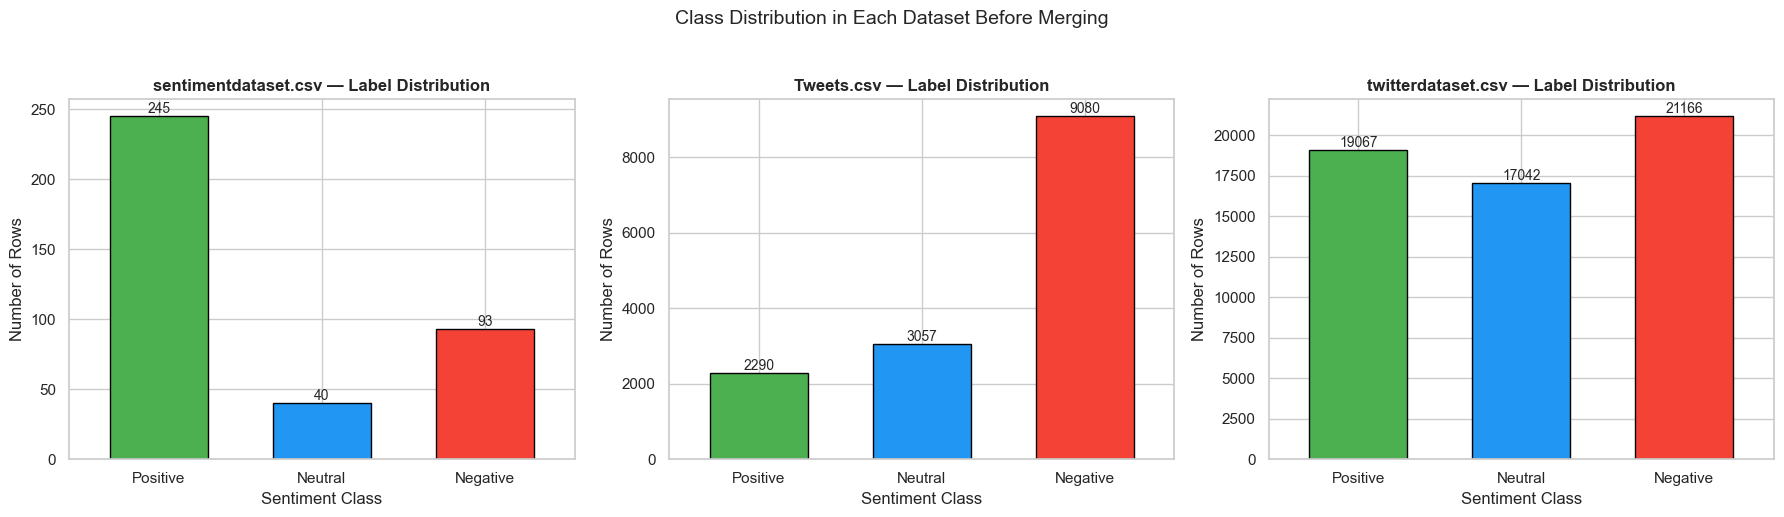

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Keep the same class order and colors across all plots
sentiment_order = ['Positive', 'Neutral', 'Negative']
sentiment_colors = {
    'Positive': '#4CAF50',
    'Neutral': '#2196F3',
    'Negative': '#F44336'
}
bar_colors = [sentiment_colors[s] for s in sentiment_order]

# Dataset 1: sentimentdataset.csv
df_sentiment['sentiment'].value_counts().reindex(sentiment_order, fill_value=0).plot(
    kind='bar', ax=axes[0], color=bar_colors, edgecolor='black', width=0.6
)
axes[0].set_title('sentimentdataset.csv — Label Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Rows')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

# Dataset 2: Tweets.csv
df_tweets['sentiment'].value_counts().reindex(sentiment_order, fill_value=0).plot(
    kind='bar', ax=axes[1], color=bar_colors, edgecolor='black', width=0.6
)
axes[1].set_title('Tweets.csv — Label Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Number of Rows')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

# Dataset 3: twitterdataset.csv
df_twitterdataset['sentiment'].value_counts().reindex(sentiment_order, fill_value=0).plot(
    kind='bar', ax=axes[2], color=bar_colors, edgecolor='black', width=0.6
)
axes[2].set_title('twitterdataset.csv — Label Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sentiment Class')
axes[2].set_ylabel('Number of Rows')
axes[2].tick_params(axis='x', rotation=0)
for p in axes[2].patches:
    axes[2].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.suptitle('Class Distribution in Each Dataset Before Merging', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('viz1_distribution_before_merge.png', dpi=150, bbox_inches='tight')
plt.show()

### Dropping rows where label could not be mapped and also viewing what was changed and what was not 

In [104]:
before_sentiment = len(df_sentiment)
before_tweets = len(df_tweets)
before_twitterdataset = len(df_twitterdataset)

 
df_sentiment = df_sentiment.dropna(subset=['sentiment'])
df_tweets = df_tweets.dropna(subset=['sentiment'])
df_twitterdataset = df_twitterdataset.dropna(subset=['sentiment'])
 
print("\n=== LABEL NORMALISATION ===")
print(f"df_sentiment: {before_sentiment} → {len(df_sentiment)} rows (dropped {before_sentiment - len(df_sentiment)} unmappable labels)")
print(f"df_tweets: {before_tweets} → {len(df_tweets)} rows (dropped {before_tweets - len(df_tweets)} unmappable labels)")
print(f"df_twitterdataset: {before_twitterdataset} → {len(df_twitterdataset)} rows (dropped {before_twitterdataset - len(df_twitterdataset)} unmappable labels)")

print("\ndf_sentiment label distribution after normalisation:")
print(df_sentiment['sentiment'].value_counts())
 
print("\ndf_tweets label distribution after normalisation:")
print(df_tweets['sentiment'].value_counts())

print("\ndf_twitterdataset label distribution after normalisation:")
print(df_twitterdataset['sentiment'].value_counts())
 
 


=== LABEL NORMALISATION ===
df_sentiment: 707 → 378 rows (dropped 329 unmappable labels)
df_tweets: 14427 → 14427 rows (dropped 0 unmappable labels)
df_twitterdataset: 69490 → 57275 rows (dropped 12215 unmappable labels)

df_sentiment label distribution after normalisation:
sentiment
Positive    245
Negative     93
Neutral      40
Name: count, dtype: int64

df_tweets label distribution after normalisation:
sentiment
Negative    9080
Neutral     3057
Positive    2290
Name: count, dtype: int64

df_twitterdataset label distribution after normalisation:
sentiment
Negative    21166
Positive    19067
Neutral     17042
Name: count, dtype: int64


### Merging the Datasets into one 

In [105]:
# MERGE THE TWO DATASETS

df_sentiment['source'] = 'social_media'
df_tweets['source'] = 'airline_tweets'
df_twitterdataset['source'] = 'twitterdataset'

combined_df = pd.concat([df_sentiment, df_tweets, df_twitterdataset], ignore_index=True)

print("\n=== AFTER MERGING ===")
print(f"Combined dataset → {combined_df.shape[0]} rows")
print("\nSource breakdown:")
print(combined_df['source'].value_counts())


=== AFTER MERGING ===
Combined dataset → 72080 rows

Source breakdown:
source
twitterdataset    57275
airline_tweets    14427
social_media        378
Name: count, dtype: int64


### Removing cross dataset duplicates

In [106]:
before_merge_dedup = len(combined_df)
combined_df = combined_df.drop_duplicates(subset='text').reset_index(drop=True)
print(f"\nCross-dataset duplicates removed: {before_merge_dedup - len(combined_df)}")
print(f"Combined dataset after removing duplicates → {combined_df.shape[0]} rows")

# Save a copy BEFORE balancing for later comparison charts
combined_before_balance = combined_df.copy()



Cross-dataset duplicates removed: 0
Combined dataset after removing duplicates → 72080 rows


### Balancing the Dataset by Reducing Negative Samples

In [107]:

# Reduce Negative class by 5000 samples in the combined dataset
negative_mask = combined_df['sentiment'] == 'Negative'
negative_count_before = int(negative_mask.sum())
remove_n = min(5000, negative_count_before)

if remove_n > 0:
    drop_idx = combined_df[negative_mask].sample(n=remove_n, random_state=42).index
    combined_df = combined_df.drop(index=drop_idx).reset_index(drop=True)

# Save a copy AFTER balancing
combined_balanced = combined_df.copy()

negative_count_after = int((combined_df['sentiment'] == 'Negative').sum())
print(f"Negative samples removed: {remove_n}")
print(f"Negative count: {negative_count_before} → {negative_count_after}")
print(f"Combined dataset after downsampling → {combined_df.shape[0]} rows")

Negative samples removed: 5000
Negative count: 30339 → 25339
Combined dataset after downsampling → 67080 rows


### Class Imbalance check

In [108]:
print("\n=== CLASS IMBALANCE CHECK ===")
class_counts = combined_df['sentiment'].value_counts()
print(class_counts)
 
majority = class_counts.max()
minority = class_counts.min()
imbalance_ratio = majority / minority
print(f"\nImbalance ratio (majority / minority): {imbalance_ratio:.2f}x")
 
if imbalance_ratio > 2:
    print("  Imbalance detected — balancing required")
else:
    print(" Classes are reasonably balanced")


=== CLASS IMBALANCE CHECK ===
sentiment
Negative    25339
Positive    21602
Neutral     20139
Name: count, dtype: int64

Imbalance ratio (majority / minority): 1.26x
 Classes are reasonably balanced


### Class Distribution after merging

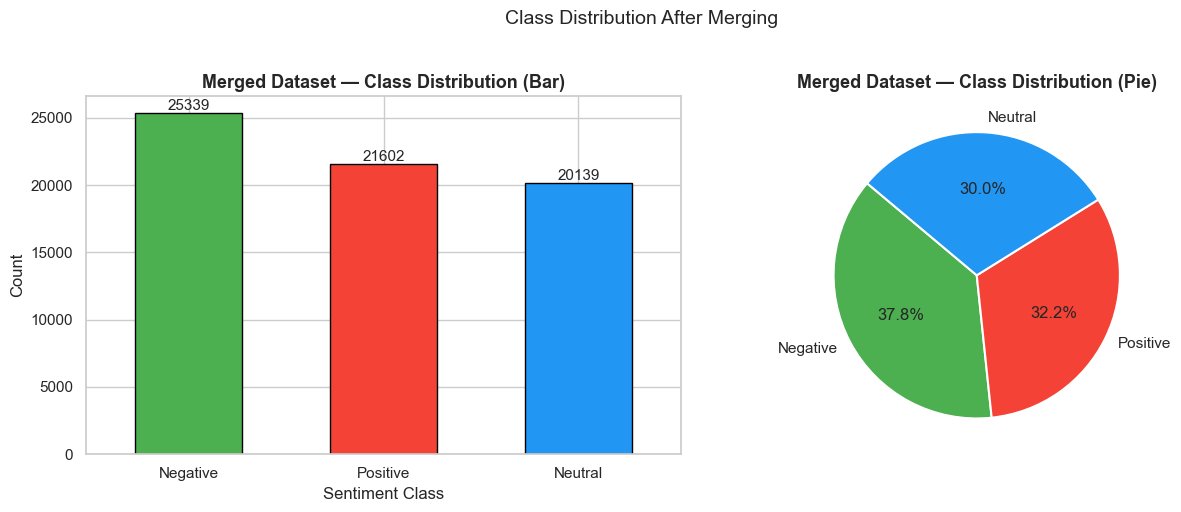

Saved: viz2_distribution_after_merge.png


In [109]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Bar chart
colors = ['#4CAF50', '#F44336', '#2196F3']
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.55)
axes[0].set_title('Merged Dataset — Class Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)
 
# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Merged Dataset — Class Distribution (Pie)', fontsize=13, fontweight='bold')
 
plt.suptitle('Class Distribution After Merging', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('viz2_distribution_after_merge.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz2_distribution_after_merge.png")
 
 

###   Before vs After balancing visualisation (side by side)

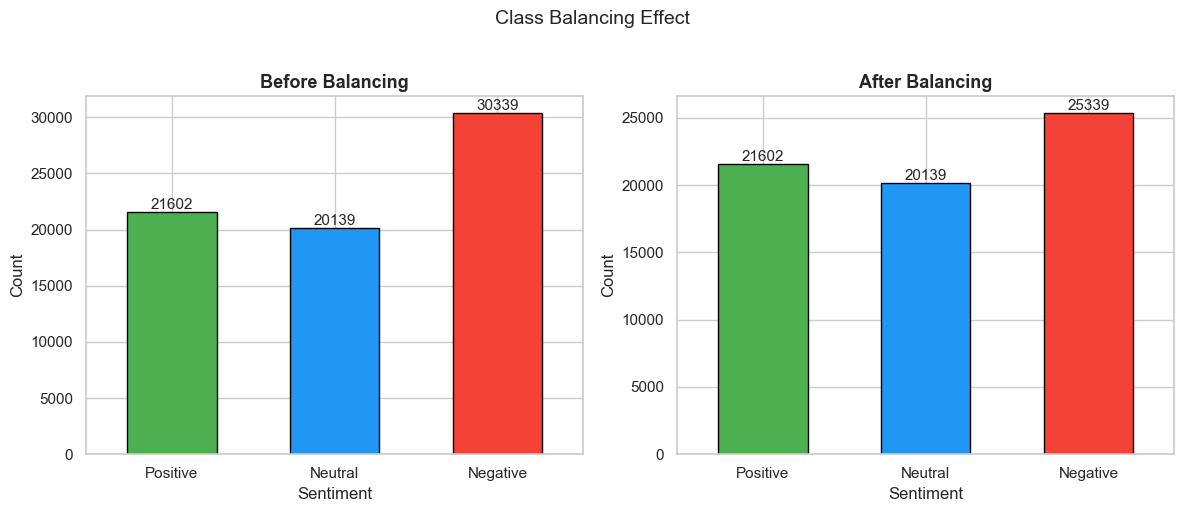

Saved: viz3_balancing_effect.png


In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sentiment_order = ['Positive', 'Neutral', 'Negative']
sentiment_colors = {
    'Positive': '#4CAF50',
    'Neutral': '#2196F3',
    'Negative': '#F44336'
}
bar_colors = [sentiment_colors[s] for s in sentiment_order]

before_counts = combined_before_balance['sentiment'].value_counts().reindex(sentiment_order, fill_value=0)
after_counts = combined_balanced['sentiment'].value_counts().reindex(sentiment_order, fill_value=0)

before_counts.plot(kind='bar', ax=axes[0], color=bar_colors, edgecolor='black', width=0.55)
axes[0].set_title('Before Balancing', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

after_counts.plot(kind='bar', ax=axes[1], color=bar_colors, edgecolor='black', width=0.55)
axes[1].set_title('After Balancing', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

plt.suptitle('Class Balancing Effect', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('viz3_balancing_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz3_balancing_effect.png')

###  Text length distribution by sentiment class

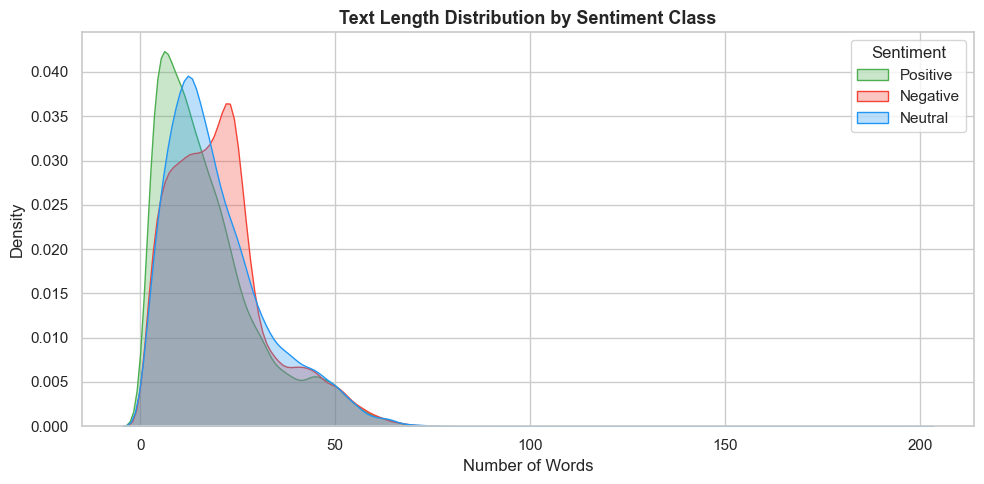

Saved: viz4_text_length_distribution.png


In [111]:
# This helps us understand whether positive/negative/neutral posts
# tend to be longer or shorter — useful context for the report.
combined_balanced['text_length'] = combined_balanced['text'].str.split().str.len()
 
plt.figure(figsize=(10, 5))
for label, color in zip(['Positive', 'Negative', 'Neutral'], colors):
    subset = combined_balanced[combined_balanced['sentiment'] == label]['text_length']
    sns.kdeplot(subset, label=label, color=color, fill=True, alpha=0.3)
 
plt.title('Text Length Distribution by Sentiment Class', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Density')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('viz4_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz4_text_length_distribution.png")

### Source contribution to final dataset visualisation



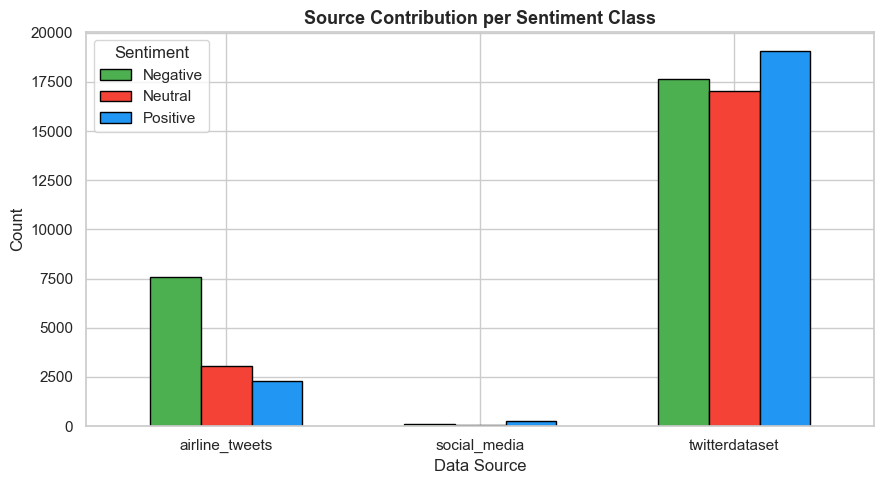

Saved: viz5_source_contribution.png


In [112]:
# Shows how much each original dataset contributed after balancing.
 
source_sentiment = combined_balanced.groupby(
    ['source', 'sentiment']
).size().unstack(fill_value=0)
 
source_sentiment.plot(
    kind='bar', color=colors, edgecolor='black', width=0.6, figsize=(9, 5)
)
plt.title('Source Contribution per Sentiment Class', fontsize=13, fontweight='bold')
plt.xlabel('Data Source')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('viz5_source_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz5_source_contribution.png")

### Split and Save Training and Validation sets

In [113]:
final_df = combined_balanced[['text', 'sentiment']].copy()

train_df, val_df = train_test_split(
    final_df,
    test_size=0.30,
    random_state=42,
    stratify=final_df['sentiment']
)

train_path = 'data/processed/processed_training_dataset.csv'
val_path = 'data/processed/processed_validation_datset.csv'

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)

print("\n=== FINAL SUMMARY ===")
print(f"Training dataset saved: {train_path} — {len(train_df)} rows")
print(f"Validation dataset saved: {val_path} — {len(val_df)} rows")

print("\nTraining class distribution:")
print(train_df['sentiment'].value_counts())

print("\nValidation class distribution:")
print(val_df['sentiment'].value_counts())


=== FINAL SUMMARY ===
Training dataset saved: data/processed/processed_training_dataset.csv — 46956 rows
Validation dataset saved: data/processed/processed_validation_datset.csv — 20124 rows

Training class distribution:
sentiment
Negative    17737
Positive    15122
Neutral     14097
Name: count, dtype: int64

Validation class distribution:
sentiment
Negative    7602
Positive    6480
Neutral     6042
Name: count, dtype: int64


## 5.2 Test Data Preprocessing and Cleaning

### Dropping Duplicates

In [114]:

df_gmail = df_gmail.drop_duplicates(subset=['text']).reset_index(drop=True)
df_whatsapp = df_whatsapp.drop_duplicates(subset=['text']).reset_index(drop=True)

print(f"Gmail records after deduplication: {len(df_gmail)}")
print(f"WhatsApp records after deduplication: {len(df_whatsapp)}")

Gmail records after deduplication: 348
WhatsApp records after deduplication: 318


 We define a robust cleaning function using regular expressions to strip signatures, HTML, and specific noise markers identified during EDA.

In [115]:
def clean_the_text(text):
    # Remove HTML tags (<div>, <br>, etc.)
    text = re.sub(r'<.*?>', '', text)
    
    # Remove Forwarded message markers and signatures
    text = re.sub(r'--- Forwarded message ---', '', text)
    text = re.sub(r'Please consider the environment', '', text, flags=re.I)
    text = re.sub(r'Sent from my (iPhone|mobile|Android|iPhone)', '', text, flags=re.I)
    text = re.sub(r'Best regards, .*', '', text, flags=re.I)
    
    # Remove service markers (MTN:, GitHub:, etc.)
    text = re.sub(r'(MTN|GitHub|Vercel|Udemy|Vultr|CodeMagic|LinkedIn|Amazon|Railway|Netlify|Heroku):', '', text, flags=re.I)

    # Remove specific noise characters (!!!, ???, @user)
    text = re.sub(r'!!!|\?\?\?|@user', '', text)
    
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


### Applying the clean the text fucntion to the datasets

In [116]:
df_gmail['clean_text'] = df_gmail['text'].apply(clean_the_text)
df_whatsapp['clean_text'] = df_whatsapp['text'].apply(clean_the_text)


### First five columns of the Data

In [117]:

df_gmail[['text', 'clean_text']].head()

,text,clean_text
0,@user GitHub: Security alert - A new SSH key w...,Security alert - A new SSH key was added.
1,!!! Vultr: Monthly invoice is ready for review...,Monthly invoice is ready for review.
2,<br> Coursera: Financial Aid for 'Machine Lear...,Coursera: Financial Aid for 'Machine Learning'...
3,@user Udemy: Registration Successful! Welcome ...,Registration Successful! Welcome to 'Deep Lear...
4,??? You've won a $1000 prize! Claim your rewar...,You've won a $1000 prize! Claim your reward now!


## Dropping the columns that are not needed & Merging the two datasets
We drop the 'noise' columns (meta_data, priority, is_starred, etc.) and merge the two streams into a unified testing dataset.

In [118]:
# Tag sources before merging for visualization
df_gmail['source'] = 'Gmail'
df_whatsapp['source'] = 'WhatsApp'

# Select final columns
gmail_final = df_gmail[['clean_text', 'sentiment', 'source']].rename(columns={'clean_text': 'text'})
whatsapp_final = df_whatsapp[['clean_text', 'sentiment', 'source']].rename(columns={'clean_text': 'text'})

# Merge
test_dataset = pd.concat([gmail_final, whatsapp_final], ignore_index=True)
test_dataset = test_dataset.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Final Test Dataset Size after deduplication: {len(test_dataset)}")

Final Test Dataset Size after deduplication: 177


### Visualising the test Data distribution

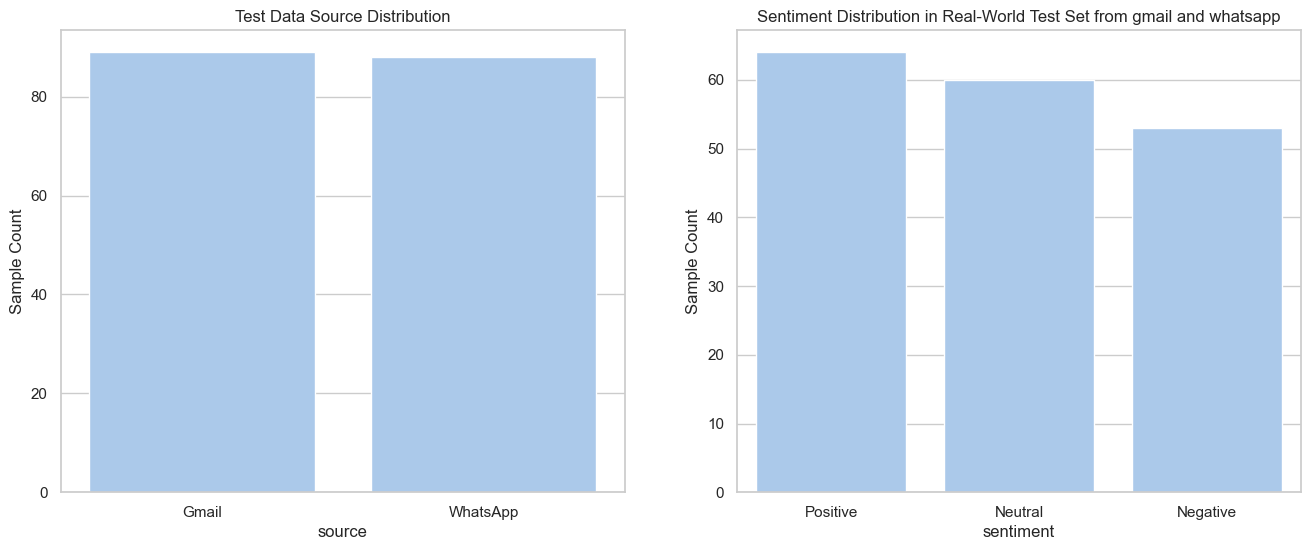

In [119]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Source Contribution
sns.countplot(data=test_dataset, x='source', ax=ax[0])
ax[0].set_title('Test Data Source Distribution')
ax[0].set_ylabel('Sample Count')

# 2. Sentiment Distribution (Verification of Balance)
sns.countplot(data=test_dataset, x='sentiment', ax=ax[1], order=['Positive', 'Neutral', 'Negative'])
ax[1].set_title('Sentiment Distribution in Real-World Test Set from gmail and whatsapp')
ax[1].set_ylabel('Sample Count')

plt.show()

### Test length Analysis

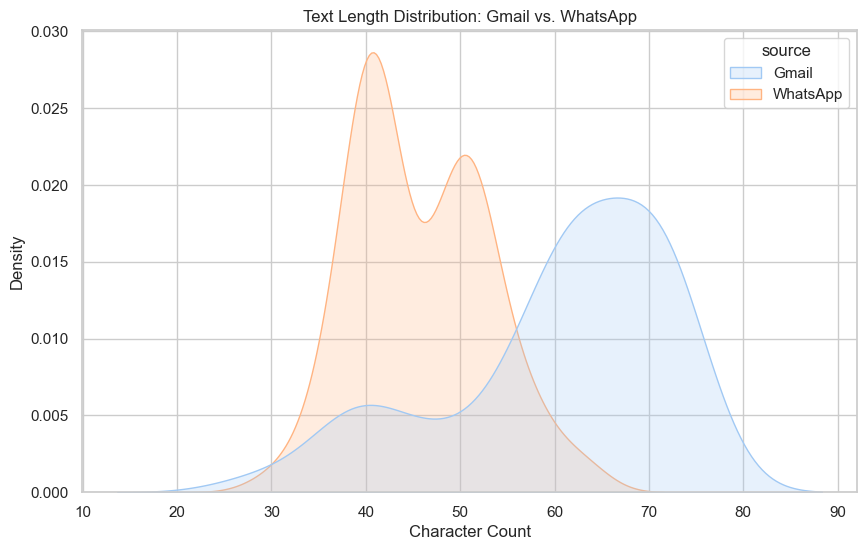

In [120]:
test_dataset['char_count'] = test_dataset['text'].apply(len)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=test_dataset, x='char_count', hue='source', fill=True)
plt.title('Text Length Distribution: Gmail vs. WhatsApp')
plt.xlabel('Character Count')
plt.show()

In [121]:
output_path = 'data/processed/student_test_dataset.csv'
test_dataset[['text', 'sentiment']].to_csv(output_path, index=False)
print(f"Success! Cleaned test set saved to: {output_path}")

Success! Cleaned test set saved to: data/processed/student_test_dataset.csv


### Exporting to the processed data folder

## 6. Feature Engineering 

In [ ]:
def extract_meta_features(df):
    df = df.copy()
    df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))
    df['question_count'] = df['text'].apply(lambda x: str(x).count('?'))
    df['is_all_caps'] = df['text'].apply(lambda x: 1 if str(x).isupper() and len(str(x)) > 5 else 0)
    df['char_cnt'] = df['text'].apply(lambda x: len(str(x)))
    df['word_cnt'] = df['text'].apply(lambda x: len(str(x).split()))
    platforms = r'github|slack|coursera|udemy|paystack|railway|netlify|heroku|mtn|airtel|gmail|whatsapp'
    alerts = r'invoice|billing|service termination|payment receipt|account alert|reminder notice|transaction'
    academic = r'assignment|deadline|exam|results|semester|lecture|submission|grade|marks|course'
    df['has_platform_mention'] = df['text'].apply(lambda x: 1 if re.search(platforms, str(x).lower()) else 0)
    df['has_service_alert'] = df['text'].apply(lambda x: 1 if re.search(alerts, str(x).lower()) else 0)
    df['student_context_score'] = df['text'].apply(lambda x: len(re.findall(academic, str(x).lower())))
    df['positive_signal'] = df['text'].apply(lambda x: len(re.findall(r'congrats|congratulations|proud|excited|happy|amazing|passed|accepted|scholarship|won|celebrate|excellent|well done', str(x).lower())))
    return df



def surgical_cleaner(text):
    if not isinstance(text, str): return ""
    text = text.lower(); text = re.sub(r'http\S+', '', text); text = text.translate(str.maketrans('', '', string.punctuation)); text = re.sub(r'\s+', ' ', text).strip()
    return text if text else "notification"




# 1. Apply Metadata Extraction and Surgical Cleaning
train_df = extract_meta_features(train_df)
test_df  = extract_meta_features(test_df)

train_df['clean'] = train_df['text'].apply(surgical_cleaner)
test_df['clean']  = test_df['text'].apply(surgical_cleaner)

# 2. Map Categorical Sentiments to Numeric Labels
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
train_df['label'] = train_df['sentiment'].map(label_map)
test_df['label']  = test_df['sentiment'].map(label_map)

y_train, y_test = train_df['label'].values, test_df['label'].values

# 3. Visualize the "Domain Shift" Representation
train_counts = train_df['sentiment'].value_counts(normalize=True).sort_index()
test_counts = test_df['sentiment'].value_counts(normalize=True).sort_index()

pd.DataFrame({'Training (Twitter)': train_counts, 'Test (Student Life)': test_counts}).plot(
    kind='bar', color=['skyblue', 'salmon'], figsize=(10, 5)
)
plt.title('Visualizing the Domain Shift Challenge')
plt.ylabel('Percentage of Messages')
plt.show()







fig, ax = plt.subplots(figsize=(10, 6)); ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
m_names = ['Naive Bayes', 'LogReg', 'SVM', 'RF', 'MLP', 'CNN', 'LSTM', 'BiLSTM', 'BiGRU', 'BERT']
for i, m in enumerate(m_names): 
    ax.add_patch(FancyBboxPatch((0.5, 9-i*0.8), 2, 0.5, boxstyle="round,pad=0.1", ec="black", fc="lightgray"))
    ax.text(1.5, 9.25-i*0.8, m, ha='center', va='center', fontsize=9)
ax.add_patch(FancyBboxPatch((6, 4.5), 2.5, 1, boxstyle="round,pad=0.1", ec="red", fc="mistyrose"))
ax.text(7.25, 5, 'XGBoost Manager', ha='center', va='center', fontweight='bold')
ax.annotate('', xy=(6, 5), xytext=(3, 5), arrowprops=dict(arrowstyle='->', lw=2))
plt.title('Our 10-Model Stacking Ensemble Architecture'); plt.show()

meta_cols = ['exclamation_count', 'question_count', 'is_all_caps', 'char_cnt', 'word_cnt', 'has_platform_mention', 'has_service_alert', 'student_context_score', 'positive_signal']
scaler = StandardScaler(); X_train_meta = scaler.fit_transform(train_df[meta_cols]); X_test_meta  = scaler.transform(test_df[meta_cols])




VOCAB_SIZE, MAX_LEN = 20000, 150
dl_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
dl_tokenizer.fit_on_texts(train_df['clean'])

glove_path = 'glove.6B.100d.txt'
if not os.path.exists(glove_path):
    urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', 'glove.6B.zip')
    with zipfile.ZipFile('glove.6B.zip', 'r') as z: z.extract(glove_path)

embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f: 
        v = line.split()
        embeddings_index[v[0]] = np.asarray(v[1:], dtype='float32')

embedding_matrix = np.zeros((VOCAB_SIZE, 100))
for word, i in dl_tokenizer.word_index.items():
    if i < VOCAB_SIZE: 
        vec = embeddings_index.get(word)
        if vec is not None: embedding_matrix[i] = vec


## 7. Ensemble Model Training & Evaluation 
---

In [ ]:
class SentiDS(torch.utils.data.Dataset):
        def __init__(self, enc, lbl): self.enc = enc; self.lbl = lbl
        def __getitem__(self, idx): 
            item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
            item['labels'] = torch.tensor(self.lbl[idx]); return item
        def __len__(self): return len(self.lbl)

def train_distilbert(train_txt, train_lbl):
    from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
    tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
    train_enc = tokenizer(train_txt.tolist(), truncation=True, padding=True, max_length=128)
    model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3).to(DEVICE)
    args = TrainingArguments(output_dir='results', num_train_epochs=3, per_device_train_batch_size=8, gradient_accumulation_steps=4, learning_rate=2e-5, warmup_ratio=0.1, weight_decay=0.01, dataloader_pin_memory=False, fp16=True, disable_tqdm=True, save_strategy='no', logging_strategy='no')
    trainer = Trainer(model=model, args=args, train_dataset=SentiDS(train_enc, train_lbl))
    trainer.train(); return model, tokenizer


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
train_predictions = np.zeros((len(train_df), 30)); test_predictions = np.zeros((len(test_df), 30))
cw_dict = {i: compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)[i] for i in range(3)}; all_histories = []; fold_accuracies = []

for fold, (t_idx, v_idx) in enumerate(skf.split(train_df['clean'], y_train)):
    print(f"\n--- WORKING ON FOLD {fold+1} ---")
    vec = TfidfVectorizer(max_features=15000, ngram_range=(1,2), sublinear_tf=True); vec.fit(train_df['clean'].iloc[t_idx])
    X_t_tfidf = vec.transform(train_df['clean'].iloc[t_idx]); X_v_tfidf = vec.transform(train_df['clean'].iloc[v_idx]); X_test_tfidf_f = vec.transform(test_df['clean'])
    X_t_seq = pad_sequences(dl_tokenizer.texts_to_sequences(train_df['clean'].iloc[t_idx]), maxlen=MAX_LEN)
    X_v_seq = pad_sequences(dl_tokenizer.texts_to_sequences(train_df['clean'].iloc[v_idx]), maxlen=MAX_LEN)
    X_test_seq_f = pad_sequences(dl_tokenizer.texts_to_sequences(test_df['clean']), maxlen=MAX_LEN)
    
    print("Training Naive Bayes..."); nb = MultinomialNB().fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 0:3] = nb.predict_proba(X_v_tfidf); test_predictions[:, 0:3] += nb.predict_proba(X_test_tfidf_f) / 5; del nb; print("Done!")
    
    print("Training Logistic Regression..."); lr = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 3:6] = lr.predict_proba(X_v_tfidf); test_predictions[:, 3:6] += lr.predict_proba(X_test_tfidf_f) / 5; del lr; print("Done!")
    
    print("Training SVM..."); svm = CalibratedClassifierCV(LinearSVC(class_weight='balanced'), cv=3).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 6:9] = svm.predict_proba(X_v_tfidf); test_predictions[:, 6:9] += svm.predict_proba(X_test_tfidf_f) / 5; del svm; print("Done!")
    
    print("Training Random Forest..."); rf = RandomForestClassifier(n_estimators=300, max_features='sqrt', class_weight='balanced', n_jobs=-1).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 9:12] = rf.predict_proba(X_v_tfidf); test_predictions[:, 9:12] += rf.predict_proba(X_test_tfidf_f) / 5; del rf; print("Done!")
    
    print("Training MLP..."); mlp = MLPClassifier(hidden_layer_sizes=(256,128,64), max_iter=300, early_stopping=True, validation_fraction=0.1).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 12:15] = mlp.predict_proba(X_v_tfidf); test_predictions[:, 12:15] += mlp.predict_proba(X_test_tfidf_f) / 5; del mlp; print("Done!")
    
    # Deep Learning explicit unrolling
    print("Training CNN..."); es_cnn = EarlyStopping(patience=2, restore_best_weights=True)
    i_cnn = Input(shape=(MAX_LEN,)); x_cnn = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_cnn); x_cnn = SpatialDropout1D(0.3)(x_cnn); x_cnn = Conv1D(128, 5, activation='relu')(x_cnn)
    cnn_model = Model(inputs=i_cnn, outputs=Dense(3, activation='softmax')(GlobalMaxPooling1D()(x_cnn)))
    cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam'); h = cnn_model.fit(X_t_seq, y_train[t_idx], epochs=10, batch_size=64, verbose=0, callbacks=[es_cnn], class_weight=cw_dict)
    if fold==0: all_histories.append(('CNN', h))
    train_predictions[v_idx, 15:18] = cnn_model.predict(X_v_seq); test_predictions[:, 15:18] += cnn_model.predict(X_test_seq_f) / 5; del cnn_model; tf.keras.backend.clear_session(); gc.collect(); print("Done!")
    
    print("Training LSTM..."); es_lstm = EarlyStopping(patience=2, restore_best_weights=True)
    i_lstm = Input(shape=(MAX_LEN,)); x_lstm = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_lstm); x_lstm = SpatialDropout1D(0.3)(x_lstm); x_lstm = LSTM(128)(x_lstm)
    lstm_model = Model(inputs=i_lstm, outputs=Dense(3, activation='softmax')(x_lstm))
    lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam'); h = lstm_model.fit(X_t_seq, y_train[t_idx], epochs=10, batch_size=64, verbose=0, callbacks=[es_lstm], class_weight=cw_dict)
    if fold==0: all_histories.append(('LSTM', h))
    train_predictions[v_idx, 18:21] = lstm_model.predict(X_v_seq); test_predictions[:, 18:21] += lstm_model.predict(X_test_seq_f) / 5; del lstm_model; tf.keras.backend.clear_session(); gc.collect(); print("Done!")

    print("Training Bi-LSTM..."); es_bilstm = EarlyStopping(patience=2, restore_best_weights=True)
    i_bi = Input(shape=(MAX_LEN,)); x_bi = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_bi); x_bi = SpatialDropout1D(0.3)(x_bi); x_bi = Bidirectional(LSTM(64))(x_bi)
    bi_model = Model(inputs=i_bi, outputs=Dense(3, activation='softmax')(x_bi))
    bi_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam'); h = bi_model.fit(X_t_seq, y_train[t_idx], epochs=10, batch_size=64, verbose=0, callbacks=[es_bilstm], class_weight=cw_dict)
    if fold==0: all_histories.append(('Bi-LSTM', h))
    train_predictions[v_idx, 21:24] = bi_model.predict(X_v_seq); test_predictions[:, 21:24] += bi_model.predict(X_test_seq_f) / 5; del bi_model; tf.keras.backend.clear_session(); gc.collect(); print("Done!")

    print("Training Bi-GRU..."); es_bigru = EarlyStopping(patience=2, restore_best_weights=True)
    i_gru = Input(shape=(MAX_LEN,)); x_gru = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(i_gru); x_gru = SpatialDropout1D(0.3)(x_gru); x_gru = Bidirectional(GRU(64))(x_gru)
    gru_model = Model(inputs=i_gru, outputs=Dense(3, activation='softmax')(x_gru))
    gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam'); h = gru_model.fit(X_t_seq, y_train[t_idx], epochs=10, batch_size=64, verbose=0, callbacks=[es_bigru], class_weight=cw_dict)
    if fold==0: all_histories.append(('Bi-GRU', h))
    train_predictions[v_idx, 24:27] = gru_model.predict(X_v_seq); test_predictions[:, 24:27] += gru_model.predict(X_test_seq_f) / 5; del gru_model; tf.keras.backend.clear_session(); gc.collect(); print("Done!")

    print("Training DistilBERT..."); bm, bt = train_distilbert(train_df['clean'].iloc[t_idx], y_train[t_idx]); bm.eval()
    with torch.no_grad():
        def get_p(tl): 
            res = []
            for j in range(0, len(tl), 32): 
                batch = tl[j:j+32]; e = bt(batch, return_tensors='pt', padding=True, truncation=True, max_length=128).to(DEVICE)
                res.append(torch.softmax(bm(**e).logits, dim=-1).cpu().numpy())
            return np.vstack(res)
        train_predictions[v_idx, 27:30] = get_p(train_df['clean'].iloc[v_idx].tolist())
        test_predictions[:, 27:30] += get_p(test_df['clean'].tolist()) / 5
    del bm; torch.cuda.empty_cache(); gc.collect(); fold_accuracies.append(accuracy_score(y_train[v_idx], np.argmax(train_predictions[v_idx], axis=1))); print("Done!")
print(f"\nEnsemble Stability: {np.mean(fold_accuracies):.2%} ± {np.std(fold_accuracies):.2%}")



In [ ]:
X_stack_train = np.hstack([train_predictions, X_train_meta]); X_stack_test = np.hstack([test_predictions, X_test_meta])
final_model = xgb.XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0, objective='multi:softprob', use_label_encoder=False, eval_metric='mlogloss', early_stopping_rounds=50)
final_model.fit(X_stack_train, y_train, eval_set=[(X_stack_test, y_test)], verbose=False)
y_final = final_model.predict(X_stack_test); y_final_probs = final_model.predict_proba(X_stack_test)
f_names = []
for m in m_names: f_names.extend([f"{m}_Neg", f"{m}_Neu", f"{m}_Pos"])
f_names.extend(meta_cols)
pd.DataFrame({'F': f_names, 'I': final_model.feature_importances_}).sort_values('I', ascending=False).head(15).plot(kind='bar', x='F'); plt.show()

## 8. Comparative Analysis & Performance Comparison
---

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for i, (name, h) in enumerate(all_histories): ax[i].plot(h.history['loss']); ax[i].set_title(name)
plt.show()
accs = [accuracy_score(y_train, np.argmax(train_predictions[:, i*3:i*3+3], axis=1)) for i in range(10)]
pd.DataFrame({'Model': m_names, 'Acc': accs}).sort_values('Acc').plot(kind='barh', x='Model', y='Acc'); plt.show()

## 9. Model Interpretability (SHAP & LIME)

In [ ]:
for i, name in enumerate(m_names):
    print(f"\n--- {name} Individual Report ---")
    print(classification_report(y_test, np.argmax(test_predictions[:, i*3:i*3+3], axis=1), target_names=label_map.keys()))

y_test_bin = label_binarize(y_test, classes=[0,1,2])
plt.figure(figsize=(10, 6))
for i, cls in enumerate(['Negative','Neutral','Positive']):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_final_probs[:,i]); plt.plot(fpr, tpr, label=f'{cls} AUC={auc(fpr,tpr):.2f}')
plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.title('ROC Curves Per Class'); plt.show()

wrong_idx = np.where(y_final != y_test)[0]


## 10. Top 10 Hardest Messages To Predict

In [ ]:
print("\n--- Top 10 Hardest Messages (Misclassifications) ---")
display(pd.DataFrame({'Raw Text': test_df['text'].iloc[wrong_idx].values[:10], 'True': [list(label_map.keys())[y_test[i]] for i in wrong_idx[:10]], 'Pred': [list(label_map.keys())[y_final[i]] for i in wrong_idx[:10]]}))

print("\n--- Ablation Study: Component Value Proof ---")
def quick_xgb(X): return accuracy_score(y_test, xgb.XGBClassifier(n_estimators=100, max_depth=4).fit(X_stack_train[:,:X.shape[1]], y_train).predict(X))
display(pd.DataFrame({'Configuration': ['All 10 Models + Metadata', 'No Metadata', 'No BERT + No Metadata'], 'Accuracy': [accuracy_score(y_test, y_final), quick_xgb(X_stack_test[:, :30]), quick_xgb(X_stack_test[:, :27])]}))

explainer = shap.TreeExplainer(final_model); shap_values = explainer.shap_values(X_stack_test)
shap.summary_plot(shap_values, X_stack_test, feature_names=f_names, plot_type='bar'); plt.show()
explainer_lime = LimeTabularExplainer(X_stack_train, feature_names=f_names, class_names=list(label_map.keys()), mode='classification')
def show_lime(li, title):
    idx = np.where((y_final == li) & (y_test == li))[0][0]
    print(f"--- LIME story for {title} case ---\nRaw: {test_df['text'].iloc[idx]}")
    explainer_lime.explain_instance(X_stack_test[idx], final_model.predict_proba, num_features=10).as_pyplot_figure(); plt.show()
show_lime(0, "Negative"); show_lime(1, "Neutral"); show_lime(2, "Positive")
plt.hist(np.max(y_final_probs, axis=1), bins=20, color='purple'); plt.title('Ensemble Confidence Distribution'); plt.show()
print(classification_report(y_test, y_final, target_names=label_map.keys()))
sns.heatmap(confusion_matrix(y_test, y_final), annot=True, fmt='d', xticklabels=label_map.keys(), yticklabels=label_map.keys()); plt.show()

## 11. Conclusion & Technical Recommendations
*Summary of which model is best for production and why.*